In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

In [ ]:
# Install geospatial library for TIFF handling
!pip install -q rasterio

import os
import shutil
import tarfile
import random
import torch
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from glob import glob
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from google.colab import userdata, drive

In [ ]:
# GitHub Sync Setup
GITHUB_PAT = userdata.get('MA_colab_github_PAT') # Or your specific Secret name
GITHUB_USERNAME = "MagicMorgigi"
GITHUB_EMAIL = "f.morgalla@campus.tu-berlin.de"
REPO_NAME = "master_thesis_FM"
BRANCH = "main"

# Toggle for optional pulling
PULL_LATEST = False

# Define where your existing repository lives
# (Update this if you are keeping the repo directly on Drive)
REPO_DIR = f"/content/drive/MyDrive/{REPO_NAME}"

if not os.path.exists(REPO_DIR):
    print(f"Error: Directory {REPO_DIR} does not exist. Ensure your repository is located here.")
else:
    os.chdir(REPO_DIR)

    # 1. Setup Identity (Required per Colab session)
    !git config user.name "{GITHUB_USERNAME}"
    !git config user.email "{GITHUB_EMAIL}"

    # 2. Configure Remote Authentication
    # Safely updates the remote URL to include your current PAT
    AUTH_URL = f"https://{GITHUB_PAT}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"
    !git remote set-url origin {AUTH_URL}

    # 3. Optional Pulling
    if PULL_LATEST:
        print(f"Pulling latest changes from origin/{BRANCH}...")
        !git pull origin {BRANCH}
    else:
        print("Git sync complete. Pulling skipped.")

    print(f"Successfully synced. Current working directory: {os.getcwd()}")

In [ ]:
@dataclass(frozen=True)
class Config:
    # Environment & Device
    DEVICE: torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    SEED: int = 42

    # Data Paths (Update these with your actual Drive paths)
    DRIVE_ARCHIVES: tuple = (
        '/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/packed_compressed_data/tar_gz_archives/s1_data/6%_sampled/train.tar.gz',
        '/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/packed_compressed_data/tar_gz_archives/labels/6%_sampled/train.tar.gz',
        '/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/packed_compressed_data/tar_gz_archives/s1_data/6%_sampled/val.tar.gz',
        '/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/packed_compressed_data/tar_gz_archives/labels/6%_sampled/val.tar.gz',
        '/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/packed_compressed_data/tar_gz_archives/s1_data/6%_sampled/test.tar.gz',
        '/content/drive/MyDrive/Colab_Notebooks/Datasets/BioMassters/packed_compressed_data/tar_gz_archives/labels/6%_sampled/test.tar.gz'
    )
    LOCAL_DATA_DIR: str = '/content/local_data'


    # Model & Training Hyperparameters
    IN_CHANNELS: int = 2
    OUT_CHANNELS: int = 1
    BATCH_SIZE: int = 2
    LEARNING_RATE: float = 1e-4
    EPOCHS: int = 1000
    PATIENCE: int = 50 # Early stopping
    NUM_WORKERS: int = 2

    # Feature Flags & Customizations
    STANDARDIZE: bool = True

    EXCLUDE_HIGH_VALUES: bool = False
    THRESHOLD: float = 400.0

    PENALIZE_RANGE: bool = False
    PENALTY_MIN: float = 5.0
    PENALTY_MAX: float = 300.0
    PENALTY_FACTOR: float = 1.5

    EXPERIMENT_NAME = "UNet_base_v1"
    if EXCLUDE_HIGH_VALUES:
        EXPERIMENT_NAME += f"_HiThresh{str(THRESHOLD).split('.')[0]}"
    if PENALIZE_RANGE:
        EXPERIMENT_NAME += f"PenRange{str(PENALTY_MIN).split('.')[0]}-{str(PENALTY_MAX).split('.')[0]}\
        _PenFact{(int(str(PENALTY_FACTOR).split('.')[0])-1)*100+(int(str(PENALTY_FACTOR).split('.')[1])*10)}%"
    if not STANDARDIZE:
        EXPERIMENT_NAME += "_NoStand"

    EXPERIMENT_NAME += f"_EP{EPOCHS}_BS{BATCH_SIZE}_LR{str(LEARNING_RATE).split('.')[1]}_SEED{SEED}"

    OUTPUT_DIR: str = f'/content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet/experiments/{EXPERIMENT_NAME}'

config = Config()
os.makedirs(config.OUTPUT_DIR, exist_ok=True)

In [ ]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False # Set to True if input sizes are perfectly constant, but False guarantees reproducibility

seed_everything(config.SEED)

In [ ]:
def extract_archives(archives, dest_dir):
    os.makedirs(dest_dir, exist_ok=True)

    # Explicitly map the 6 archives to their unique downstream folder names
    # This matches the order defined in config.DRIVE_ARCHIVES
    target_folders = [
        'train_input', 'train_label',
        'val_input', 'val_label',
        'test_input', 'test_label'
    ]

    for archive_path, folder_name in zip(archives, target_folders):
        if not os.path.exists(archive_path):
            print(f"Warning: {archive_path} not found.")
            continue

        # Use the unique logical name instead of the original filename to prevent collisions
        local_archive_path = os.path.join(dest_dir, f"{folder_name}.tar.gz")
        extract_folder = os.path.join(dest_dir, folder_name)

        if os.path.exists(extract_folder):
            print(f"Skipping {folder_name} - already extracted.")
            continue

        print(f"Copying {os.path.basename(archive_path)} to local storage as {folder_name}.tar.gz...")
        shutil.copy2(archive_path, local_archive_path)

        print(f"Extracting to folder: {folder_name}...")
        with tarfile.open(local_archive_path, 'r:gz') as tar:
            # The hasattr check safely resolves the DeprecationWarning shown in your output
            # for newer Python versions, while avoiding errors on older ones.
            if hasattr(tarfile, 'data_filter'):
                tar.extractall(path=extract_folder, filter='data')
            else:
                tar.extractall(path=extract_folder)

        print(f"Deleting local archive {folder_name}.tar.gz...\n")
        os.remove(local_archive_path)

# Execute Extraction
extract_archives(config.DRIVE_ARCHIVES, config.LOCAL_DATA_DIR)

Skipping train_input - already extracted.
Skipping train_label - already extracted.
Skipping val_input - already extracted.
Skipping val_label - already extracted.
Skipping test_input - already extracted.
Skipping test_label - already extracted.


In [ ]:
class AGB_Dataset(Dataset):
    def __init__(self, input_dir, label_dir, config, stats=None):
        self.config = config
        self.input_paths = glob(os.path.join(input_dir, "**", "*_S1_10.tif"), recursive=True)
        self.samples = self._map_files(self.input_paths, label_dir)
        self.stats = stats

    def _map_files(self, input_paths, label_dir):
        samples = []
        for inp in input_paths:
            basename = os.path.basename(inp)
            file_id = basename.split('_')[0]
            label_path = os.path.join(label_dir, f"{file_id}_agbm.tif")
            if os.path.exists(label_path):
                samples.append((inp, label_path, file_id))
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        inp_path, lbl_path, file_id = self.samples[idx]

        with rasterio.open(inp_path) as src:
            # Read first two bands (ASC VV, ASC VH)
            sar_data = src.read([1, 2]).astype(np.float32)

        with rasterio.open(lbl_path) as src:
            agbm_data = src.read(1).astype(np.float32)

        sar_tensor = torch.from_numpy(sar_data)
        agbm_tensor = torch.from_numpy(agbm_data).unsqueeze(0)

        if self.config.STANDARDIZE and self.stats:
            mean, std = self.stats
            # Broadcast mean/std across spatial dimensions
            sar_tensor = (sar_tensor - mean.view(2, 1, 1)) / (std.view(2, 1, 1) + 1e-8)

        return sar_tensor, agbm_tensor, file_id

def calculate_or_load_stats(train_dataset, config):
    stats_path = os.path.join(config.OUTPUT_DIR, 'standardization_stats.pt')
    if os.path.exists(stats_path):
        print("Loading existing standardization stats...")
        return torch.load(stats_path)

    print("Calculating standardization stats from training data...")
    loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, num_workers=config.NUM_WORKERS)

    sum_ = torch.zeros(config.IN_CHANNELS)
    sum_sq_ = torch.zeros(config.IN_CHANNELS)
    num_pixels = 0

    for inputs, _, _ in tqdm(loader, desc="Calculating Stats"):
        # inputs shape: (B, C, H, W)
        b, c, h, w = inputs.shape
        sum_ += inputs.sum(dim=[0, 2, 3])
        sum_sq_ += (inputs ** 2).sum(dim=[0, 2, 3])
        num_pixels += b * h * w

    mean = sum_ / num_pixels
    std = torch.sqrt((sum_sq_ / num_pixels) - (mean ** 2))

    stats = (mean, std)
    torch.save(stats, stats_path)
    return stats

In [ ]:
class CustomRegressionLoss(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

    def forward(self, pred, target):
        mse = (pred - target) ** 2
        weight = torch.ones_like(target)

        if self.config.PENALIZE_RANGE:
            penalty_mask = (target >= self.config.PENALTY_MIN) & (target <= self.config.PENALTY_MAX)
            weight[penalty_mask] = self.config.PENALTY_FACTOR

        weighted_mse = mse * weight

        if self.config.EXCLUDE_HIGH_VALUES:
            valid_mask = target <= self.config.THRESHOLD
            weighted_mse = weighted_mse[valid_mask]

        if weighted_mse.numel() == 0:
            return torch.tensor(0.0, device=pred.device, requires_grad=True)

        return weighted_mse.mean()

class MetricsAccumulator:
    """Calculates exact global metrics without storing individual pixel values in RAM."""
    def __init__(self, config):
        self.config = config
        self.reset()

    def reset(self):
        self.total_sse = 0.0       # Sum of Squared Errors
        self.total_sae = 0.0       # Sum of Absolute Errors
        self.sum_target = 0.0      # Sum of all target values
        self.sum_sq_target = 0.0   # Sum of squared target values
        self.total_pixels = 0      # Total valid pixels N

    @torch.no_grad()
    def update(self, pred, target):
        if self.config.EXCLUDE_HIGH_VALUES:
            mask = target <= self.config.THRESHOLD
            pred = pred[mask]
            target = target[mask]

        if pred.numel() == 0:
            return

        self.total_pixels += pred.numel()

        # Accumulate error terms
        self.total_sse += torch.sum((pred - target) ** 2).item()
        self.total_sae += torch.sum(torch.abs(pred - target)).item()

        # Accumulate target statistics for R2
        self.sum_target += torch.sum(target).item()
        self.sum_sq_target += torch.sum(target ** 2).item()

    def compute(self):
        if self.total_pixels == 0:
            return 0.0, 0.0, 0.0, 0.0

        mse = self.total_sse / self.total_pixels
        rmse = np.sqrt(mse)
        mae = self.total_sae / self.total_pixels

        # Exact Global R2 Calculation
        ss_res = self.total_sse
        ss_tot = self.sum_sq_target - ((self.sum_target ** 2) / self.total_pixels)
        r2 = (1.0 - ss_res / ss_tot) if ss_tot != 0 else 0.0

        return mse, rmse, mae, r2

In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1):
        super().__init__()

        # --- ENCODER (Downsampling) ---
        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # --- BOTTLENECK ---
        self.bottleneck = DoubleConv(512, 1024)
        # Modification 2: Dropout (p=0.5) added to the bottleneck
        self.dropout = nn.Dropout(p=0.5)

        # --- DECODER (Upsampling) ---
        # Modification 3 & 4 & 5: Hardcoded ConvTranspose2d, no dynamic padding blocks
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up4 = DoubleConv(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up3 = DoubleConv(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up2 = DoubleConv(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up1 = DoubleConv(128, 64)

        # --- FINAL OUTPUT ---
        # Modification 1: Output clamped using ReLU
        self.outc = nn.Sequential(
            nn.Conv2d(64, out_channels, kernel_size=1),
            nn.ReLU()
        )

    def forward(self, x):
        # Encoder Path
        x1 = self.down1(x)
        x2 = self.down2(self.pool1(x1))
        x3 = self.down3(self.pool2(x2))
        x4 = self.down4(self.pool3(x3))

        # Bottleneck Path
        x5 = self.bottleneck(self.pool4(x4))
        x5 = self.dropout(x5) # Applying dropout

        # Decoder Path with skip connections (Concatenation over channel dim)
        x = self.upconv4(x5)
        x = torch.cat([x, x4], dim=1)
        x = self.up4(x)

        x = self.upconv3(x)
        x = torch.cat([x, x3], dim=1)
        x = self.up3(x)

        x = self.upconv2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x)

        x = self.upconv1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up1(x)

        # Output Path
        return self.outc(x)

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, config):
    history = []
    best_val_loss = float('inf')
    epochs_no_improve = 0
    metrics_tracker = MetricsAccumulator(config)

    for epoch in range(1, config.EPOCHS + 1):
        # --- TRAINING ---
        model.train()
        train_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{config.EPOCHS} [Train]")
        for inputs, targets, _ in pbar:
            inputs, targets = inputs.to(config.DEVICE), targets.to(config.DEVICE)

            optimizer.zero_grad()
            preds = model(inputs)
            loss = criterion(preds, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        avg_train_loss = train_loss / len(train_loader)

        # --- VALIDATION ---
        model.eval()
        val_loss = 0.0
        metrics_tracker.reset() # Reset the global accumulators for the new epoch

        with torch.no_grad():
            for inputs, targets, _ in tqdm(val_loader, desc=f"Epoch {epoch}/{config.EPOCHS} [Val]"):
                inputs, targets = inputs.to(config.DEVICE), targets.to(config.DEVICE)
                preds = model(inputs)

                loss = criterion(preds, targets)
                val_loss += loss.item()

                # Update running totals with current batch
                metrics_tracker.update(preds, targets)

        # Compute exact global metrics for the whole validation set
        val_mse, val_rmse, val_mae, val_r2 = metrics_tracker.compute()
        avg_val_loss = val_loss / len(val_loader)

        epoch_data = {
            'epoch': epoch,
            'train_mse': avg_train_loss,
            'val_mse': avg_val_loss, # Used for Early Stopping
            'val_rmse': val_rmse,
            'val_mae': val_mae,
            'val_r2': val_r2
        }
        history.append(epoch_data)

        print(f"Epoch {epoch} | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f} | Val RMSE: {val_rmse:.4f} | Val R2: {val_r2:.4f}")

        # Early Stopping & Model Checkpointing
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join(config.OUTPUT_DIR, 'best_unet_model.pth'))
            print("=> Saved new best model.")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= config.PATIENCE:
                print(f"Early stopping triggered after {epoch} epochs.")
                break

    # Save History and Plot
    df_history = pd.DataFrame(history)
    df_history.to_csv(os.path.join(config.OUTPUT_DIR, 'training_history.csv'), index=False)

    plt.figure(figsize=(10, 6))
    plt.plot(df_history['epoch'], df_history['train_mse'], label='Train MSE')
    plt.plot(df_history['epoch'], df_history['val_mse'], label='Validation MSE')
    plt.xlabel('Epochs')
    plt.ylabel('MSE')
    plt.title('Training and Validation Loss Curve')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(config.OUTPUT_DIR, 'training_curve.png'))
    plt.close()

    return df_history

In [ ]:
# Setup Paths (Assuming extraction created folders named exactly like the tar.gz without extension)
train_in_dir = os.path.join(config.LOCAL_DATA_DIR, 'train_input')
train_lbl_dir = os.path.join(config.LOCAL_DATA_DIR, 'train_label')
val_in_dir = os.path.join(config.LOCAL_DATA_DIR, 'val_input')
val_lbl_dir = os.path.join(config.LOCAL_DATA_DIR, 'val_label')

# Initialize Train Dataset (without stats first to calculate them)
temp_train_dataset = AGB_Dataset(train_in_dir, train_lbl_dir, config, stats=None)
stats = calculate_or_load_stats(temp_train_dataset, config) if config.STANDARDIZE else None

# Final Datasets & Loaders
train_dataset = AGB_Dataset(train_in_dir, train_lbl_dir, config, stats=stats)
val_dataset = AGB_Dataset(val_in_dir, val_lbl_dir, config, stats=stats)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=config.NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS, pin_memory=True)

# Initialize Model, Loss, and Optimizer
model = UNet(in_channels=config.IN_CHANNELS, out_channels=config.OUT_CHANNELS).to(config.DEVICE)
criterion = CustomRegressionLoss(config)
optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

# Run Training
print("Starting Training...")
history_df = train_model(model, train_loader, val_loader, criterion, optimizer, config)

Calculating standardization stats from training data...


Calculating Stats:   0%|          | 0/417 [00:00<?, ?it/s]

Starting Training...


Epoch 1/1000 [Train]:   0%|          | 0/417 [00:00<?, ?it/s]

Epoch 1/1000 [Val]:   0%|          | 0/105 [00:00<?, ?it/s]

...

Epoch 75/1000 [Val]:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch 75 | Train MSE: 1046.5731 | Val MSE: 2982.2666 | Val RMSE: 54.6101 | Val R2: 0.4821


Epoch 76/1000 [Train]:   0%|          | 0/417 [00:00<?, ?it/s]

Epoch 76/1000 [Val]:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch 76 | Train MSE: 1042.7834 | Val MSE: 2996.1307 | Val RMSE: 54.7369 | Val R2: 0.4797
Early stopping triggered after 76 epochs.


In [ ]:
def run_inference(num_visualizations=5):
    # Load Stats and Best Model
    stats_path = os.path.join(config.OUTPUT_DIR, 'standardization_stats.pt')
    stats = torch.load(stats_path) if config.STANDARDIZE and os.path.exists(stats_path) else None

    model = UNet(in_channels=config.IN_CHANNELS, out_channels=config.OUT_CHANNELS).to(config.DEVICE)
    model.load_state_dict(torch.load(os.path.join(config.OUTPUT_DIR, 'best_unet_model.pth')))
    model.eval()

    test_in_dir = os.path.join(config.LOCAL_DATA_DIR, 'test_input')
    test_lbl_dir = os.path.join(config.LOCAL_DATA_DIR, 'test_label')
    test_dataset = AGB_Dataset(test_in_dir, test_lbl_dir, config, stats=stats)

    # Using configured batch size for faster inference
    test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

    # Initialize the Exact Metrics Tracker
    metrics_tracker = MetricsAccumulator(config)

    vis_count = 0
    fig, axes = plt.subplots(num_visualizations, 2, figsize=(10, 5 * num_visualizations))
    if num_visualizations == 1: axes = [axes] # Handle edge case for single row

    print("Starting evaluation on the test set...")
    with torch.no_grad():
        for inputs, targets, file_ids in tqdm(test_loader, desc="Inference"):
            inputs, targets = inputs.to(config.DEVICE), targets.to(config.DEVICE)
            preds = model(inputs)

            # Update running totals for exact global metrics
            metrics_tracker.update(preds, targets)

            # Unpack the batch for visualizations until we hit the requested amount
            for b_idx in range(inputs.size(0)):
                if vis_count >= num_visualizations:
                    break

                pred_img = preds[b_idx].cpu().squeeze().numpy()
                target_img = targets[b_idx].cpu().squeeze().numpy()
                file_id = file_ids[b_idx]

                # Apply mask to visualization for clarity if thresholding is active
                if config.EXCLUDE_HIGH_VALUES:
                    mask = target_img <= config.THRESHOLD
                    pred_img = np.where(mask, pred_img, np.nan)
                    target_img = np.where(mask, target_img, np.nan)

                ax_pred = axes[vis_count][0]
                ax_targ = axes[vis_count][1]

                im1 = ax_pred.imshow(pred_img, cmap='viridis', vmin=0, vmax=400)
                ax_pred.set_title(f"Prediction - ID: {file_id}")
                plt.colorbar(im1, ax=ax_pred, fraction=0.046, pad=0.04)

                im2 = ax_targ.imshow(target_img, cmap='viridis', vmin=0, vmax=400)
                ax_targ.set_title(f"Target - ID: {file_id}")
                plt.colorbar(im2, ax=ax_targ, fraction=0.046, pad=0.04)

                vis_count += 1

    # Compute exact global metrics for the whole test set
    test_mse, test_rmse, test_mae, test_r2 = metrics_tracker.compute()

    final_metrics = {
        'Test MSE': test_mse,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test R2': test_r2
    }

    plt.tight_layout()
    plt.savefig(os.path.join(config.OUTPUT_DIR, 'test_visualizations.png'))
    plt.show()

    # Save metrics text file
    print("\n=== FINAL EXACT TEST METRICS ===")
    with open(os.path.join(config.OUTPUT_DIR, 'test_metrics.txt'), 'w') as f:
        f.write("=== FINAL TEST METRICS ===\n")
        for k, v in final_metrics.items():
            line = f"{k}: {v:.4f}"
            f.write(line + "\n")
            print(line)

run_inference(num_visualizations=5)

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

In [ ]:
import gc
import torch

def extract_test_pixels(config):
    print(f"Extracting all test set pixels on device: {config.DEVICE.type.upper()}...")

    # Load Stats mapped safely to the current hardware
    stats_path = os.path.join(config.OUTPUT_DIR, 'standardization_stats.pt')
    stats = torch.load(stats_path, map_location=config.DEVICE) if config.STANDARDIZE and os.path.exists(stats_path) else None

    model = UNet(in_channels=config.IN_CHANNELS, out_channels=config.OUT_CHANNELS).to(config.DEVICE)

    # Load the best model weights mapped safely to the current hardware
    model_weights_path = os.path.join(config.OUTPUT_DIR, 'best_unet_model.pth')
    model.load_state_dict(torch.load(model_weights_path, map_location=config.DEVICE))
    model.eval()

    test_in_dir = os.path.join(config.LOCAL_DATA_DIR, 'test_input')
    test_lbl_dir = os.path.join(config.LOCAL_DATA_DIR, 'test_label')
    test_dataset = AGB_Dataset(test_in_dir, test_lbl_dir, config, stats=stats)
    test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for inputs, targets, _ in tqdm(test_loader, desc="Collecting Pixels"):
            inputs = inputs.to(config.DEVICE)
            preds = model(inputs)

            # Flatten and move to CPU immediately to preserve RAM/VRAM
            y_pred_list.append(preds.cpu().view(-1).numpy())
            y_true_list.append(targets.cpu().view(-1).numpy())

    # Concatenate into massive 1D arrays
    y_true_all = np.concatenate(y_true_list)
    y_pred_all = np.concatenate(y_pred_list)

    # Force garbage collection to clean up PyTorch hooks
    del y_true_list, y_pred_list, model, inputs, targets, preds
    gc.collect()

    # Only empty CUDA cache if CUDA is actually being used
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"Extraction complete. Total pixels: {len(y_true_all):,}")
    return y_true_all, y_pred_all

# Execute extraction
y_true_flat, y_pred_flat = extract_test_pixels(config)

Extracting all test set pixels on device: CPU...


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Extraction complete. Total pixels: 10,944,512


Density plot saved to: /content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet/experiments/UNet_base_v1_EP1000_BS2_LR0001_SEED42/density_scatter_plot.png


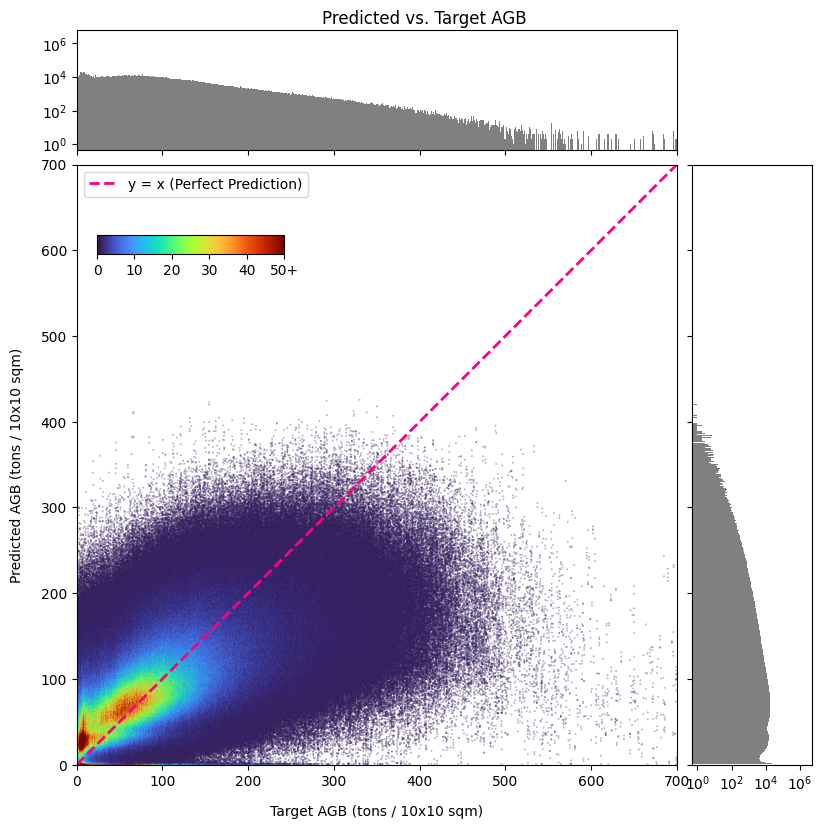

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import numpy as np

# ==============================================================================
# FREELY SELECTABLE PLOT CONFIGURATION
# ==============================================================================

# --- Scatter Axes & Resolution ---
AXES_MAX = 700.0                   # Maximum value for both X and Y axes
AXES_TICK_INTERVAL = 100.0         # Tick spacing for the main scatter plot
GRID_RESOLUTION = 3000              # Number of hexagons in the x-direction

# --- Subplot Dimensions (in inches) ---
MAIN_PLOT_SIZE = 6.0               # Width and height of the central scatter plot
HIST_HEIGHT = 1.2                  # Height of top hist / Width of right hist
HIST_DIST = 0.15                   # Spacing between main plot and marginal hists

# --- Margins (in inches) -> Determines final Figure Size ---
MARGIN_LEFT = 1.2
MARGIN_BOTTOM = 1.2
MARGIN_RIGHT = 0.8
MARGIN_TOP = 1.0

# --- Labels, Titles, and Distances ---
MAIN_TITLE = "Predicted vs. Target AGB"
TITLE_PAD = 20.0                   # Distance of overall title from top elements
X_LABEL = "Target AGB (tons / 10x10 sqm)"
X_LABEL_PAD = 12.0
Y_LABEL = "Predicted AGB (tons / 10x10 sqm)"
Y_LABEL_PAD = 12.0

# --- y=x Reference Line ---
XY_LINE_COLOR = '#FF007F'          # Bright Pink (Hex)
XY_LEGEND_LOC = 'upper left'       # Position of the line legend

# --- Marginal Histograms ---
HIST_LOG_TICK_INTERVAL = 2         # Powers of 10 interval (e.g., 2 means 10^0, 10^2, 10^4...)

# --- Color Bar Details ---
CBAR_CMAP = 'turbo'
CBAR_SCALE = 'linear'                 # 'linear' or 'log'
CBAR_LINEAR_MAX = 50            # If linear, density values > this are clipped
CBAR_NUM_TICKS = 6                 # Forces uniform spacing (e.g., 6 ticks for 0 to 50k = 10k steps)

# Color bar location (Normalized figure coordinates: [left, bottom, width, height])
# Adjust these based on whether you want it horizontal/vertical or inside/outside
CBAR_POSITION_RECT = [0.15, 0.66, 0.2, 0.02]
CBAR_ORIENTATION = 'horizontal'    # 'horizontal' or 'vertical'
CBAR_TICK_SIDE = 'bottom'          # 'bottom', 'top', 'left', 'right'

# ==============================================================================
# PLOTTING ENGINE (Inside-Out Calculation)
# ==============================================================================

def plot_density_scatter(y_true, y_pred, output_dir):
    # 1. Algebraic computation of overall figure size
    fig_width = MARGIN_LEFT + MAIN_PLOT_SIZE + HIST_DIST + HIST_HEIGHT + MARGIN_RIGHT
    fig_height = MARGIN_BOTTOM + MAIN_PLOT_SIZE + HIST_DIST + HIST_HEIGHT + MARGIN_TOP

    fig = plt.figure(figsize=(fig_width, fig_height))

    # 2. Convert inches to normalized figure coordinates (0.0 to 1.0)
    main_w_norm = MAIN_PLOT_SIZE / fig_width
    main_h_norm = MAIN_PLOT_SIZE / fig_height
    hist_h_w_norm = HIST_HEIGHT / fig_width   # Width of the right histogram
    hist_h_h_norm = HIST_HEIGHT / fig_height  # Height of the top histogram
    dist_w_norm = HIST_DIST / fig_width
    dist_h_norm = HIST_DIST / fig_height

    start_x = MARGIN_LEFT / fig_width
    start_y = MARGIN_BOTTOM / fig_height

    # Define absolute axes placements: [left, bottom, width, height]
    rect_main = [start_x, start_y, main_w_norm, main_h_norm]
    rect_hist_top = [start_x, start_y + main_h_norm + dist_h_norm, main_w_norm, hist_h_h_norm]
    rect_hist_right = [start_x + main_w_norm + dist_w_norm, start_y, hist_h_w_norm, main_h_norm]

    ax_main = fig.add_axes(rect_main)
    ax_hist_top = fig.add_axes(rect_hist_top, sharex=ax_main)
    ax_hist_right = fig.add_axes(rect_hist_right, sharey=ax_main)

    # 3. Handle Color Normalization & Clipping
    if CBAR_SCALE == 'log':
        norm = mcolors.LogNorm(vmin=1)
    else:
        norm = mcolors.Normalize(vmin=0, vmax=CBAR_LINEAR_MAX)

    # 4. Main Hexbin Scatter Plot
    # mincnt=1 ensures empty bins are totally transparent
    hb = ax_main.hexbin(y_true, y_pred, gridsize=GRID_RESOLUTION, cmap=CBAR_CMAP,
                        norm=norm, mincnt=1, extent=(0, AXES_MAX, 0, AXES_MAX))

    # Plot formatting
    ax_main.set_xlim(0, AXES_MAX)
    ax_main.set_ylim(0, AXES_MAX)
    ax_main.xaxis.set_major_locator(ticker.MultipleLocator(AXES_TICK_INTERVAL))
    ax_main.yaxis.set_major_locator(ticker.MultipleLocator(AXES_TICK_INTERVAL))
    ax_main.set_xlabel(X_LABEL, labelpad=X_LABEL_PAD)
    ax_main.set_ylabel(Y_LABEL, labelpad=Y_LABEL_PAD)

    # Bright pink y=x line
    ax_main.plot([0, AXES_MAX], [0, AXES_MAX], color=XY_LINE_COLOR, linestyle='--', linewidth=2, label='y = x (Perfect Prediction)')
    ax_main.legend(loc=XY_LEGEND_LOC)

    # 5. Marginal Histograms
    # Hide shared axis tick labels to keep plot clean
    ax_hist_top.tick_params(axis="x", labelbottom=False)
    ax_hist_right.tick_params(axis="y", labelleft=False)

    bins_array = np.linspace(0, AXES_MAX, GRID_RESOLUTION)

    # Top histogram (Target distribution)
    counts_top, _, _ = ax_hist_top.hist(y_true, bins=bins_array, color='gray', log=True)
    # Right histogram (Prediction distribution)
    counts_right, _, _ = ax_hist_right.hist(y_pred, bins=bins_array, color='gray', log=True, orientation='horizontal')

    # Custom Log Ticks for Histograms (Frequency Axes)
    max_count = max(np.max(counts_top), np.max(counts_right))
    max_pow = int(np.ceil(np.log10(max_count))) if max_count > 0 else 1
    log_ticks = [10**i for i in range(0, max_pow + 1, HIST_LOG_TICK_INTERVAL)]

    ax_hist_top.set_yticks(log_ticks)
    ax_hist_right.set_xticks(log_ticks)

    # 6. Overall Title
    fig.suptitle(MAIN_TITLE, y=1.0 - (MARGIN_TOP/fig_height) + (TITLE_PAD/fig_height/100))

    # 7. Independent Custom Color Bar
    cbar_ax = fig.add_axes(CBAR_POSITION_RECT)
    cbar = plt.colorbar(hb, cax=cbar_ax, orientation=CBAR_ORIENTATION)

    # Set tick side
    if CBAR_ORIENTATION == 'horizontal':
        cbar_ax.xaxis.set_ticks_position(CBAR_TICK_SIDE)
        cbar_ax.xaxis.set_label_position(CBAR_TICK_SIDE)
    else:
        cbar_ax.yaxis.set_ticks_position(CBAR_TICK_SIDE)
        cbar_ax.yaxis.set_label_position(CBAR_TICK_SIDE)

    # Enforce Uniform Tick Spacing & Max Clipping Labels
    if CBAR_SCALE == 'linear':
        uniform_ticks = np.linspace(0, CBAR_LINEAR_MAX, CBAR_NUM_TICKS)
        cbar.set_ticks(uniform_ticks)

        # Check if actual density exceeds our enforced linear clip max
        actual_max = hb.get_array().max()
        tick_labels = [str(int(t)) for t in uniform_ticks]
        if actual_max > CBAR_LINEAR_MAX:
            tick_labels[-1] = f"{int(CBAR_LINEAR_MAX)}+"

        if CBAR_ORIENTATION == 'horizontal':
            cbar_ax.set_xticklabels(tick_labels)
        else:
            cbar_ax.set_yticklabels(tick_labels)

    elif CBAR_SCALE == 'log':
        # Create uniformly spaced log powers
        actual_max = hb.get_array().max()
        max_cbar_pow = int(np.ceil(np.log10(actual_max)))
        uniform_log_ticks = [10**i for i in np.linspace(0, max_cbar_pow, CBAR_NUM_TICKS, dtype=int)]
        cbar.set_ticks(uniform_log_ticks)

    # Save and Show
    save_path = os.path.join(output_dir, 'density_scatter_plot.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Density plot saved to: {save_path}")
    plt.show()

# Generate the plot using the arrays generated in Cell 13
plot_density_scatter(y_true_flat, y_pred_flat, config.OUTPUT_DIR)

In [ ]:
# Change to repo directory
os.chdir(REPO_DIR)

# Copy the notebook from Colab workspace to the git repo folder before pushing
# Update 'U_Net_Pipeline.ipynb' to whatever your notebook is currently named
!cp /content/U_Net_Pipeline.ipynb ./

!git add .
!git commit -m "Update U-Net pipeline codebase"
!git push origin {BRANCH}

print("Code successfully pushed to GitHub.")

In [ ]:
import time
from google.colab import runtime, drive

def shutdown_runtime():
    print("Pipeline execution finished. Preparing for shutdown...")

    # 1. Force Google Drive to flush all pending writes and unmount
    # This guarantees your models, plots, and CSVs are safely in the cloud
    print("Syncing data to Google Drive...")
    drive.flush_and_unmount()
    print("Google Drive synced and unmounted successfully.")

    # 2. Brief pause for OS-level buffer clearance
    time.sleep(3)

    print("Terminating Colab runtime to save compute units. Goodbye!")

    # 3. Gracefully unassign and delete the runtime
    runtime.unassign()

# Execute shutdown
shutdown_runtime()

Pipeline execution finished. Preparing for shutdown...
Syncing data to Google Drive...
Google Drive synced and unmounted successfully.
Terminating Colab runtime to save compute units. Goodbye!
